In [1]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.signal import correlate, correlation_lags

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
# from fitburst.analysis.model import SpectrumModeler

from astropy.constants import c
import astropy.units as u
from astropy.time import Time
import chime_frb_constants as constants

import baseband
from baseband import vdif
from baseband_tasks.shaping import Transpose, Reshape
from baseband_tasks.functions import Square, Power

In [2]:
# Default plot parameters
plt.rcParams.update({
    "figure.dpi": 300,
    "figure.figsize": (8, 6),
    "font.size": 12,
    "font.family": "serif",
    "figure.titlesize": 16,
    "axes.titlesize": 14,
    # "axes.labelsize": 12,
    # "xtick.labelsize": 12,
    # "ytick.labelsize": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    #"image.cmap": "viridis",
    # "image.interpolation": "nearest",
    "axes.grid": False,
    "savefig.bbox": "tight",
})

In [3]:
# Constants & Global Variables
SAMPLE_RATE = constants.FPGA_COUNTS_PER_SECOND * u.Hz  # time axis sampling
FCENS = np.linspace(775, 425, 8) # * u.MHz
S_LABELS = ['I', 'Q', 'U', 'V']
SOURCE_DIR = '/scratch/abernier/pulsar_data/2022_CHIME_B2111+46'

# Open Files

If X and Y are the two complex voltages (2 pols), then we have

$$ I = \left<∣X∣^2 + ∣Y∣^2\right>  $$

$$ Q = \left< |X|^2 - |Y|^2 \right> $$

$$ U = \left< 2 \, \mathrm{Re}(X Y^*) \right> $$

$$ V = \left< 2 \, \mathrm{Im}(X Y^*) \right> $$

In [4]:
def get_freq_array(freq_bands):
    """    
    Get frequency array for the specified frequency bands.

    Parameters
    ----------
    freq_bands : list of int
        List of frequency band indices to get the frequency array for. 
        Must be adjacent and sorted in increasing band order (decreasing fcen order).
    
    Returns
    -------
    freq_array : np.ndarray
        Frequency array (increasing) corresponding to the specified frequency bands, shape (Nfreqs,).
    """

    Nfreqs = int(1024/8 * len(freq_bands))  # number of freq channels within specified bands
    fstart = FCENS[freq_bands[-1]] - 25  # highest band = lowest fcen
    fstop = FCENS[freq_bands[0]] + 25

    freq_array = np.linspace(fstart, fstop, Nfreqs)
    
    return freq_array


def get_stokes(data):
    """
    Get Stokes I, Q, U, V from powers and cross terms of two polarizations.

    Parameters
    ----------
    data : np.ndarray
        Data array with shape (Ntimes, Nfreqs, Nterms). The Nterms contains the powers
        and cross terms for two polarizations. Axis is ordered as ['XX', 'YY', 'XY', 'YX'].

    Returns
    -------
    I, Q, U, V : np.ndarrays
        Stokes parameters I, Q, U, V, each with shape (Ntimes, Nfreqs).
    """
    
    I = data[:,:,0] + data[:,:,1]  # |X|^2 + |Y|^2
    Q = data[:,:,0] - data[:,:,1]  # |X|^2 - |Y|^2
    U = 2 * data[:,:,2]  # 2 Re(XY*)
    V = 2 * data[:,:,3]  # 2 Im(XY*)

    return I, Q, U, V


def downsample_data(fh, data, Nsamples_per_chunk=391):
    """
    Downsample data along the time axis. 

    Parameters
    ----------
    fh : baseband.vdif.VdifFile
        VDIF file handle from which data is read.
    data : np.ndarray
        Data array matching what is read from fh.
    Nsamples_per_chunk : int
        Number of samples the average over. Last chunk will have equal or less than this number.
    
    Returns
    -------
    data_avg : np.ndarray
        Downsampled data array with shape (Nchunks, Nfreqs, Nterms),
        where Nchunks is the number of ~1ms chunks in the file and Nterms are the powers and cross terms (4).
    """

    # Average data along time axis
    Ntimes = fh.shape[0]
    start_edges = list(range(0, Ntimes, Nsamples_per_chunk))  # Start indices for every ~1ms chunk in this file
    data_avg = np.array([np.nanmean(data[e:e+Nsamples_per_chunk], axis=0) for e in start_edges])
    
    return data_avg


def build_time(fh, time, elapsed_time, Nsamples_per_chunk=391):
    """
    Build time array for the data read from a single VDIF file. This function updates the global time array
    and the elapsed time since the start of the global time array.

    Parameters
    ----------
    fh : baseband.vdif.VdifFile
        VDIF file handle from which data is read.
    time : List
        List of times since starting to read all files. Gets extended with current file times.
    elapsed_time : float
        Total elapsed time since the start of the time array. Gets updated with current file time.
    """

    Ntimes = fh.shape[0]
    start_edges = list(range(0, Ntimes, Nsamples_per_chunk))  # Start indices for every ~1ms chunk in this file
    
    # File time info
    dt_total = (fh.stop_time - fh.start_time).sec  # dt of file
    t_file = np.linspace(0, dt_total, Ntimes)  # relative times within file, [s]

    # Time of 1ms chunks relative to start of time array
    t_data = [t_file[e] + elapsed_time for e in start_edges]
    time.extend(t_data)

    # Update time
    elapsed_time = elapsed_time + dt_total
    return elapsed_time


def get_data(fh, data_list, transpose_shape=(1,3,2)):
    """
    Read data from a single VDIF file and append to data_list.

    Parameters
    ----------
    fh : baseband.vdif.VdifFile
        VDIF file handle from which data is read. The data inside must have shape
        (Ntimes, Nchannels * Npols, Nsubbands).
    data_list : list of np.ndarray
        List containing data arrays for each opened file. List has length Nfiles, 
        and each array has shape [Nstokes, Ntimes, Nfreqs].
    transpose_shape : tuple of int
        Order of axis indices to use for transposing the loaded data when reshaping 
        to merge frequency axes. The time axis is exluded. 
        Default transposes to (Nchannels, Nsubbands, Npols).
    """

    # Reshape the data
    fh = Reshape(fh, (16,2,8))  # splitting frequency and polarization
    fh = Transpose(fh, transpose_shape)  # swapping axes so sub-bands and frequency channels are together
    fh = Reshape(fh, (128,2))  # combining sub-bands and frequency channels

    # Convert pol data to power & cross terms
    fh = Power(fh, polarization=['XX', 'YY', 'XY', 'YX'])  # Shape (Ntimes, Nfreqs, 4)
    
    # Read data
    data = fh.read()  # Shape (Ntimes, Nfreqs, Nterms)

    # Downsample to ~1ms (avg every 391 samples)
    data_avg = downsample_data(fh, data)

    # Get all Stokes parameters
    I, Q, U, V = get_stokes(data_avg)
    # Add to list of data for this band
    stokes_stack = np.array([I, Q, U, V])  # Shape: (4, Ntimes, Nfreqs)
    data_list.append(stokes_stack)


def read_files(source_dir, freq_bands, start_file_ind=0, Nfiles=100):
    """
    Read data from VDIF files in the specified frequency bands and return the Stokes parameters.

    Parameters
    ----------
    source_dir : str
        Directory containing the VDIF files organized by frequency bands.
    freq_bands : list of int
        List of frequency band indices to read data from. Indices must give a continuous range of bands.
    start_file_ind : int, optional
        Index of the first file to read in each band. Default is 0.
    Nfiles : int, optional
        Number of files to read from each band. Default is 100.
    
    Returns
    -------
    full_data : np.ndarray
        Downsampled Stokes parameters data for all bands, shape (Nstokes, Ntimes, Nfreqs).
    time : np.ndarray
        Time array corresponding to the data, shape (Ntimes,).
    freq : np.ndarray
        Frequency array corresponding to the data, shape (Nfreqs,).
    """

    # Arrays to return
    time = []  # [seconds]
    freq_bands = sorted(freq_bands)  # increasing order
    freq = get_freq_array(freq_bands)  # [MHz]
    full_data = []

    elapsed_time = 0.0  # [seconds]

    for band_index,fband in enumerate(freq_bands):
        print(f'Processing band {fband}')
        
        file_list = sorted(glob.glob(f'{source_dir}/{fband}/20220826T064420Z_CHIME_vdif/*_0{fband}.vdif'))
        band_data = []  # Stores I,Q,U,V for this band

        for file in file_list[start_file_ind:start_file_ind+Nfiles]:
            # Open file
            fh = vdif.open(file, 'rs', sample_rate=SAMPLE_RATE)  

            # Add file data to band_data (Nfiles * array[Nstokes, Ntimes_file, Nfreqs])
            get_data(fh, band_data)

            # Build time array (only for first band)
            if band_index==0:
                elapsed_time = build_time(fh, time, elapsed_time)
            
        # Reshape to (Nstokes, Ntimes, Nfreqs), all increasing
        band_data = np.concatenate(band_data, axis=1)  # Concatenate along time axis
        band_data = np.flip(band_data, axis=2)  # flip frequency axis to increasing order
        # Add to full_data
        full_data.append(band_data)

    # Flip band order & concatenate along frequency axis
    full_data = np.concatenate(full_data[::-1], axis=2)
    # Time array
    time = np.array(time)  # [s]

    return full_data, time, freq

In [24]:
freq_bands = [4,5,6]
start_file_ind = 160
Nfiles = 300

# Get Stokes data ((Nstokes, Ntimes, Nfreqs)
full_stokes, time, freq = read_files(SOURCE_DIR, 
                                     freq_bands=freq_bands, 
                                     start_file_ind=start_file_ind,
                                     Nfiles=Nfiles)

Processing band 4
Processing band 5
Processing band 6


# Plot Raw Stokes Data

In [25]:
# --- 4-panels plot function ---
def plot_stokes(data_array, freq, time, t_unit='ms', suptitle='', 
                rfi_masked=None, height_ratios=[1, 3], cbar_lim=None, 
                save=False, save_path=None):
    """
    Plot Stokes parameters I, Q, U, V in a 2x2 grid.

    Parameters
    ----------
    data_array : Array of the 4 Stokes parameters in the order I, Q, U, V. Shape (Nstokes, Ntimes, Nfreqs).
    freq : Frequency array (MHz).
    time : Time array (in t_unit).
    t_unit : Defines the unit for the time array (e.g., 'ms', 's').
    suptitle : Title for the entire figure.
    rfi_masked : List of RFI channels to highlight in red.
    height_ratios : Height ratio of the top/bottom panels for each Stokes subplot.
    cbar_lim : Stokes data array to use to set the cbar limits. When None, data_array is used.
    """
    
    # Figure info
    fig = plt.figure(figsize=(10, 11), dpi=200)
    outer = gridspec.GridSpec(2, 2, hspace=0.15, wspace=0.35)  # 2x2 grid for Stokes parameters
    extent = (time[0], time[-1], freq[0], freq[-1])
    plt.suptitle(suptitle)

    # Go through all Stokes parameters
    for i, param in enumerate(S_LABELS):
        data_plot = data_array[i]
        row = i // 2
        col = i % 2

        # Define inner grid for timeseries and Stokes parameter plots
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1,  # 2 rows: timeseries + stokes
            subplot_spec=outer[row, col],
            height_ratios=height_ratios,
            hspace=0.0  # no space between timeseries and stokes
        )

        # Add subplots
        timeseries_ax = fig.add_subplot(inner[0])
        stokes_ax = fig.add_subplot(inner[1], sharex=timeseries_ax)

        # --- Add timeseries plot ---
        timeseries = np.nanmean(data_plot, axis=1)  # Average over frequency
        timeseries_ax.scatter(time, timeseries, color='black', s=1)
        timeseries_ax.set_title(f'Stokes {param}')
        timeseries_ax.tick_params(length=0, labelbottom=False, labelleft=False)

        # --- Add Stokes parameter plot ---
        # Colorbar limits
        if cbar_lim is None:
            cbar_lim = data_plot
        vmin = np.nanpercentile(cbar_lim, 5)
        vmax = np.nanpercentile(cbar_lim, 95)
        linear = plt.cm.colors.Normalize(vmin=vmin, vmax=vmax)
        # Plot data
        im = stokes_ax.imshow(data_plot.T, 
                       origin='lower', 
                       aspect='auto', 
                       extent=extent, 
                       cmap='viridis',
                       norm=linear
                       )
        
        # --- Colorbar ---
        anchor_height = 0.39 if row==0 else 0.
        cbar = fig.colorbar(im, ax=(timeseries_ax, stokes_ax), pad=0.05, 
                        shrink=height_ratios[1]/np.sum(height_ratios) * 1.06, 
                        anchor=(1.65, anchor_height)
                        )
        # cbar.set_label(cbar_label)
        
        # --- Highlight RFI channels ---
        # if rfi_masked is not None:
        #     add_rfi_rectangles(stokes_ax, rfi_masked, freq=freq, time=time)

        # --- Axes labels ---
        if i >= 2:
            stokes_ax.set_xlabel(f'Time [{t_unit}]')
        if i % 2 == 0:
            stokes_ax.set_ylabel('Frequency [MHz]')

    
    plt.subplots_adjust(top=0.93) 

    # --- Save Figure --

    plt.show()

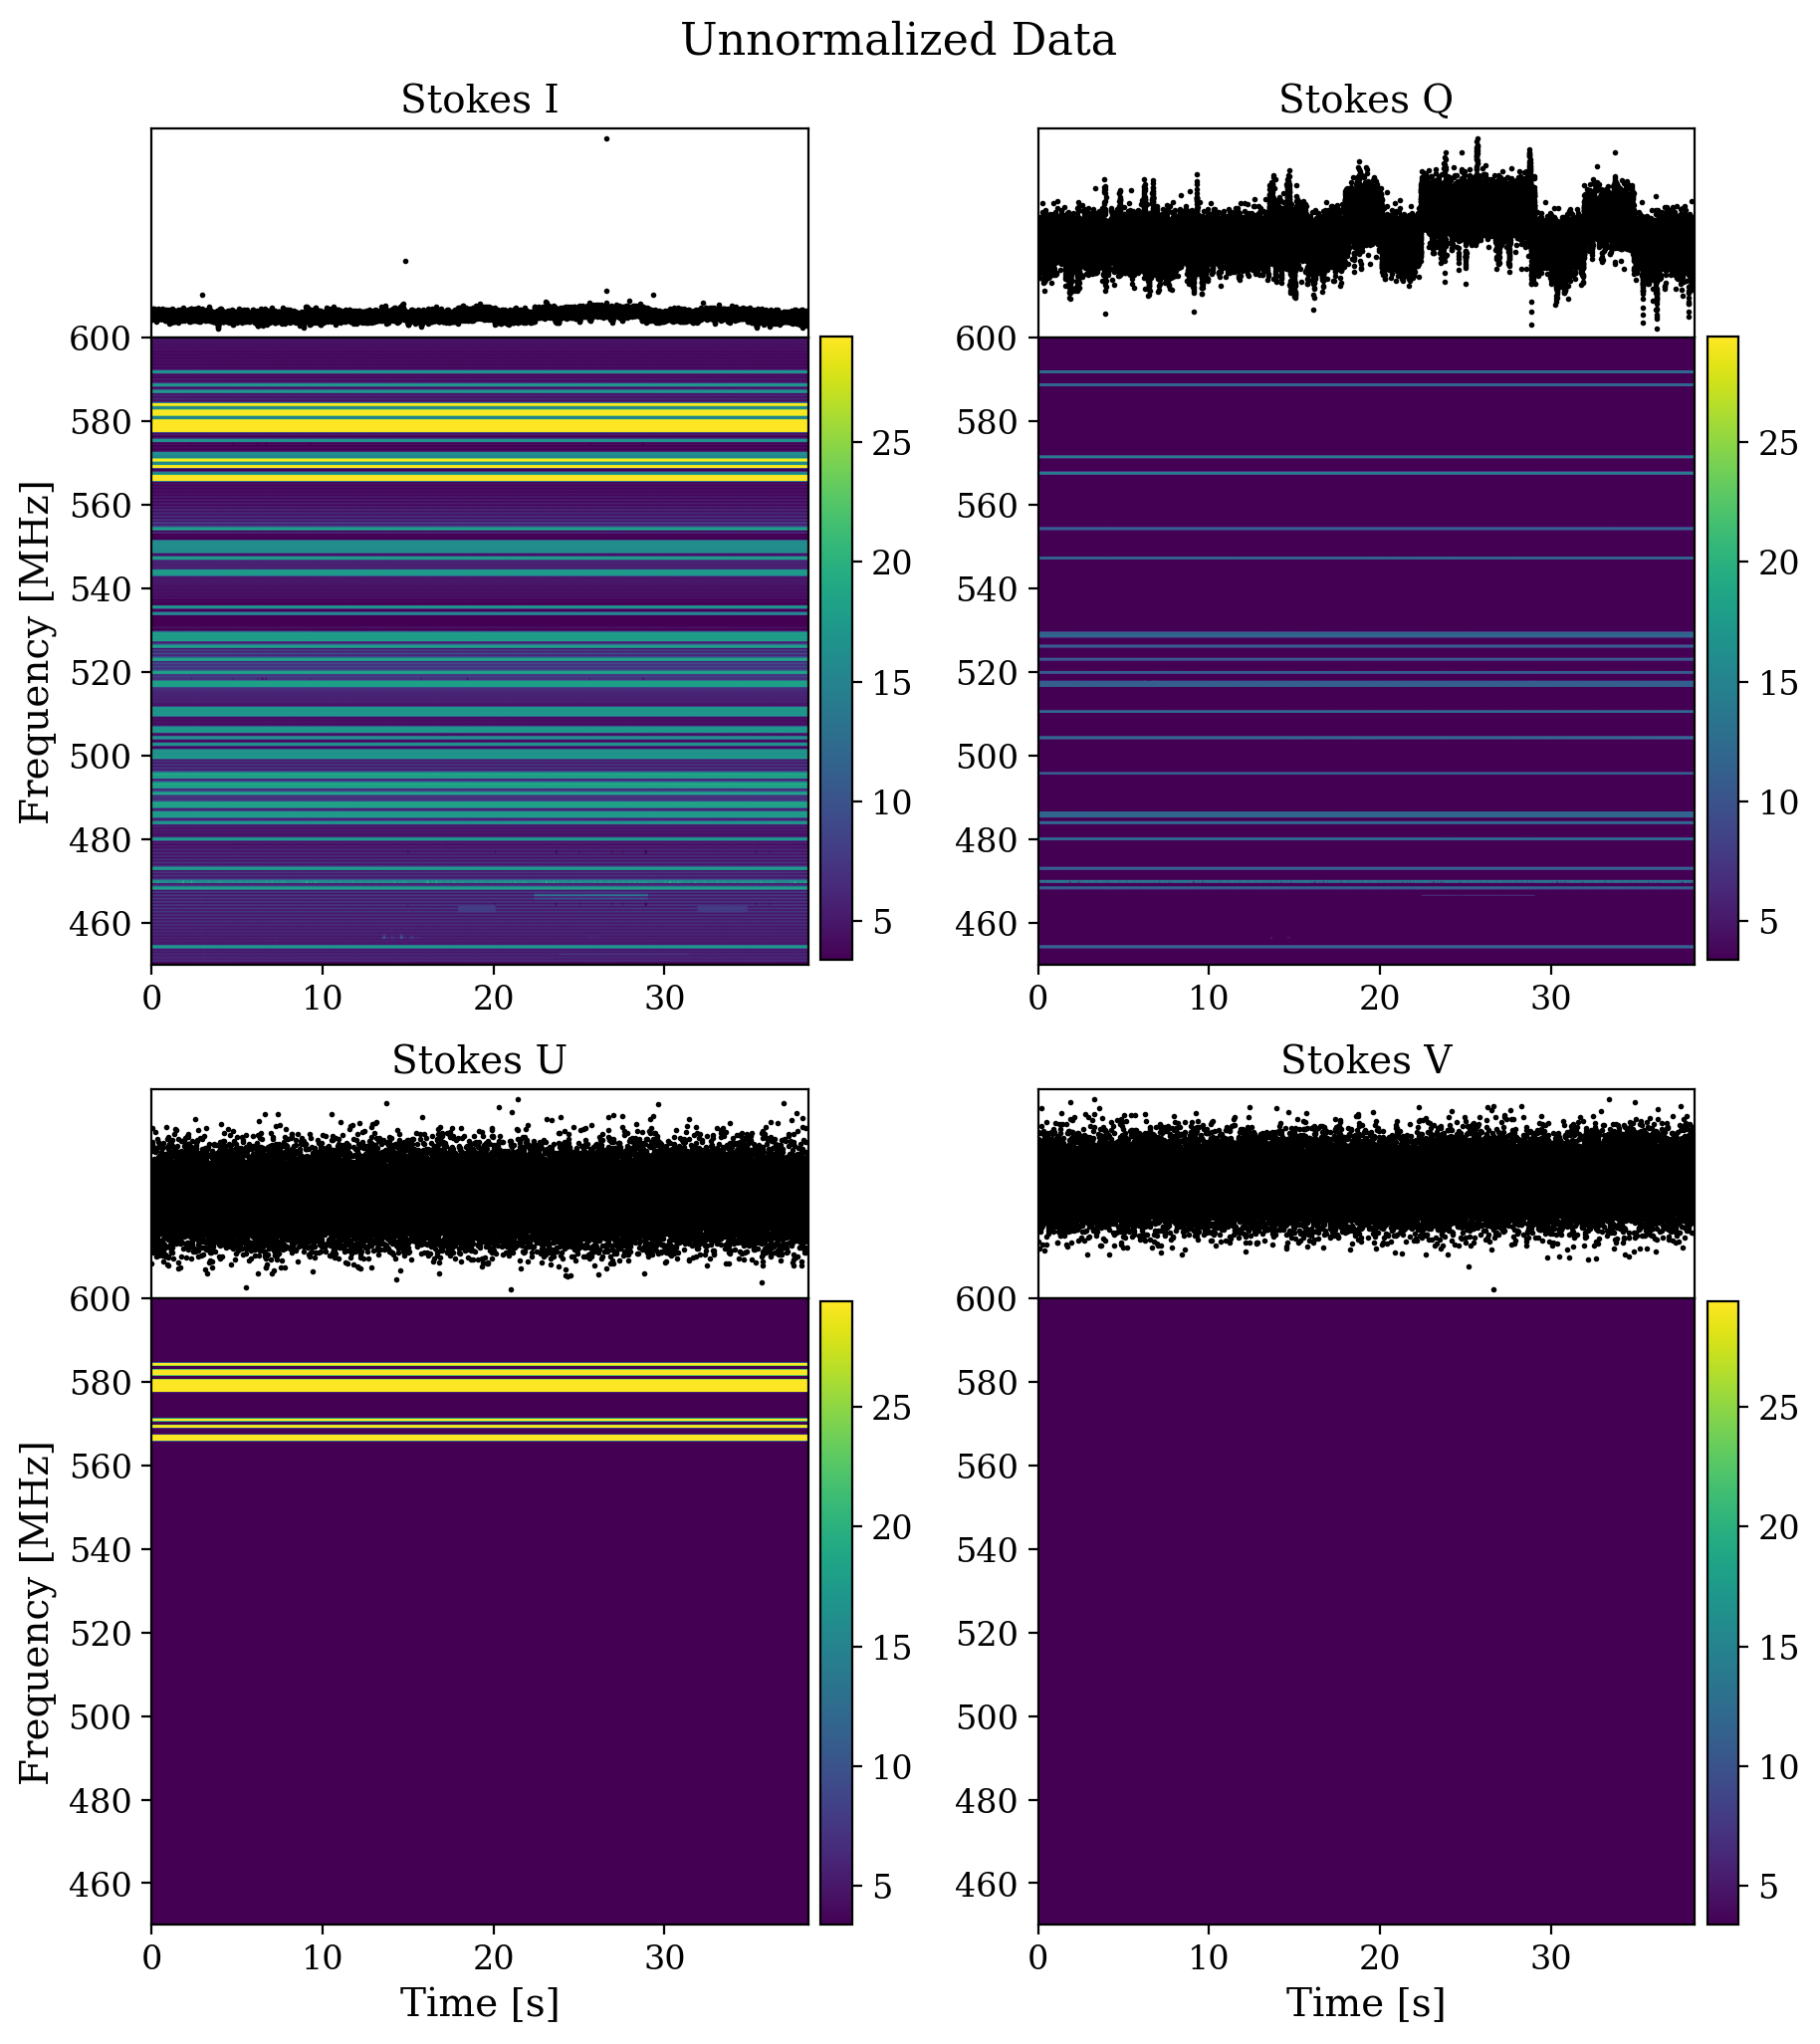

In [26]:
# Plot unnormalized data
plot_stokes(full_stokes, freq, time, t_unit='s', suptitle='Unnormalized Data')

# Mask RFI & Normalize

In [27]:
def get_rfi_mask(intensity_array, mean_treshhold=2, std_threshold=5):
    """
    Flag frequency channels with anomalous statistics across time, such as unusually high
    mean or standard deviation, which may indicate RFI. Returns a boolean mask.
    
    Parameters
    ----------
    intensity_array : np.ndarray
        Normalized intensity data with shape (Ntimes, Nfreqs), where each column is a frequency channel.
    mean_threshold : float
        Threshold for the absolute value of the mean. Channels with |mean| > mean_threshold are flagged.
    std_threshold : float
        Threshold for the standard deviation. Channels with std > std_threshold are flagged.
    
    Returns
    -------
    channel_mask : np.ndarray
        Boolean array of shape (Nfreqs,) where True indicates a flagged (to be masked) frequency channel.
    """

    # Mean and std per frequency channel (avg across time)
    mean_per_channel = np.nanmean(intensity_array, axis=0)
    std_per_channel = np.nanstd(intensity_array, axis=0)

    # Normalize & compare channel means
    means_norm = (mean_per_channel - np.mean(mean_per_channel)) / np.std(mean_per_channel)
    channel_mask_mean = np.abs(means_norm) > mean_treshhold

    # Normalize & compare channel stds
    stds_norm = (std_per_channel - np.mean(std_per_channel)) / np.std(std_per_channel)
    channel_mask_std = np.abs(stds_norm) > std_threshold
    
    # Combine masks
    channel_mask = channel_mask_mean | channel_mask_std

    return channel_mask

In [28]:
def normalize_data(data_array):
    """
    Normalize data by subtracting the mean and dividing by the standard deviation,
    computed per frequency channel (over time) for each Stokes parameter.

    Parameters
    ----------
    data_array : np.ndarray
        Array of data to normalize (shape: [Nstokes, Ntimes, Nfreqs]).

    Returns
    -------
    data_normalized : np.ndarray
        Normalized array of the same shape
    """
    
    mean_per_channel = np.nanmean(data_array, axis=1, keepdims=True)
    std_per_channel = np.nanstd(data_array, axis=1, keepdims=True)
    
    return (data_array - mean_per_channel) / std_per_channel

In [29]:
# Get RFI mask using intensity data
rfi_mask = get_rfi_mask(full_stokes[0], mean_treshhold=2, std_threshold=1.3)

# Normalize & mask RFI channels
stokes_norm_masked = normalize_data(full_stokes.copy())
stokes_norm_masked[:,:,rfi_mask] = np.nan

/tmp/ipykernel_1923138/3227340536.py:20: RuntimeWarning: invalid value encountered in divide
  return (data_array - mean_per_channel) / std_per_channel


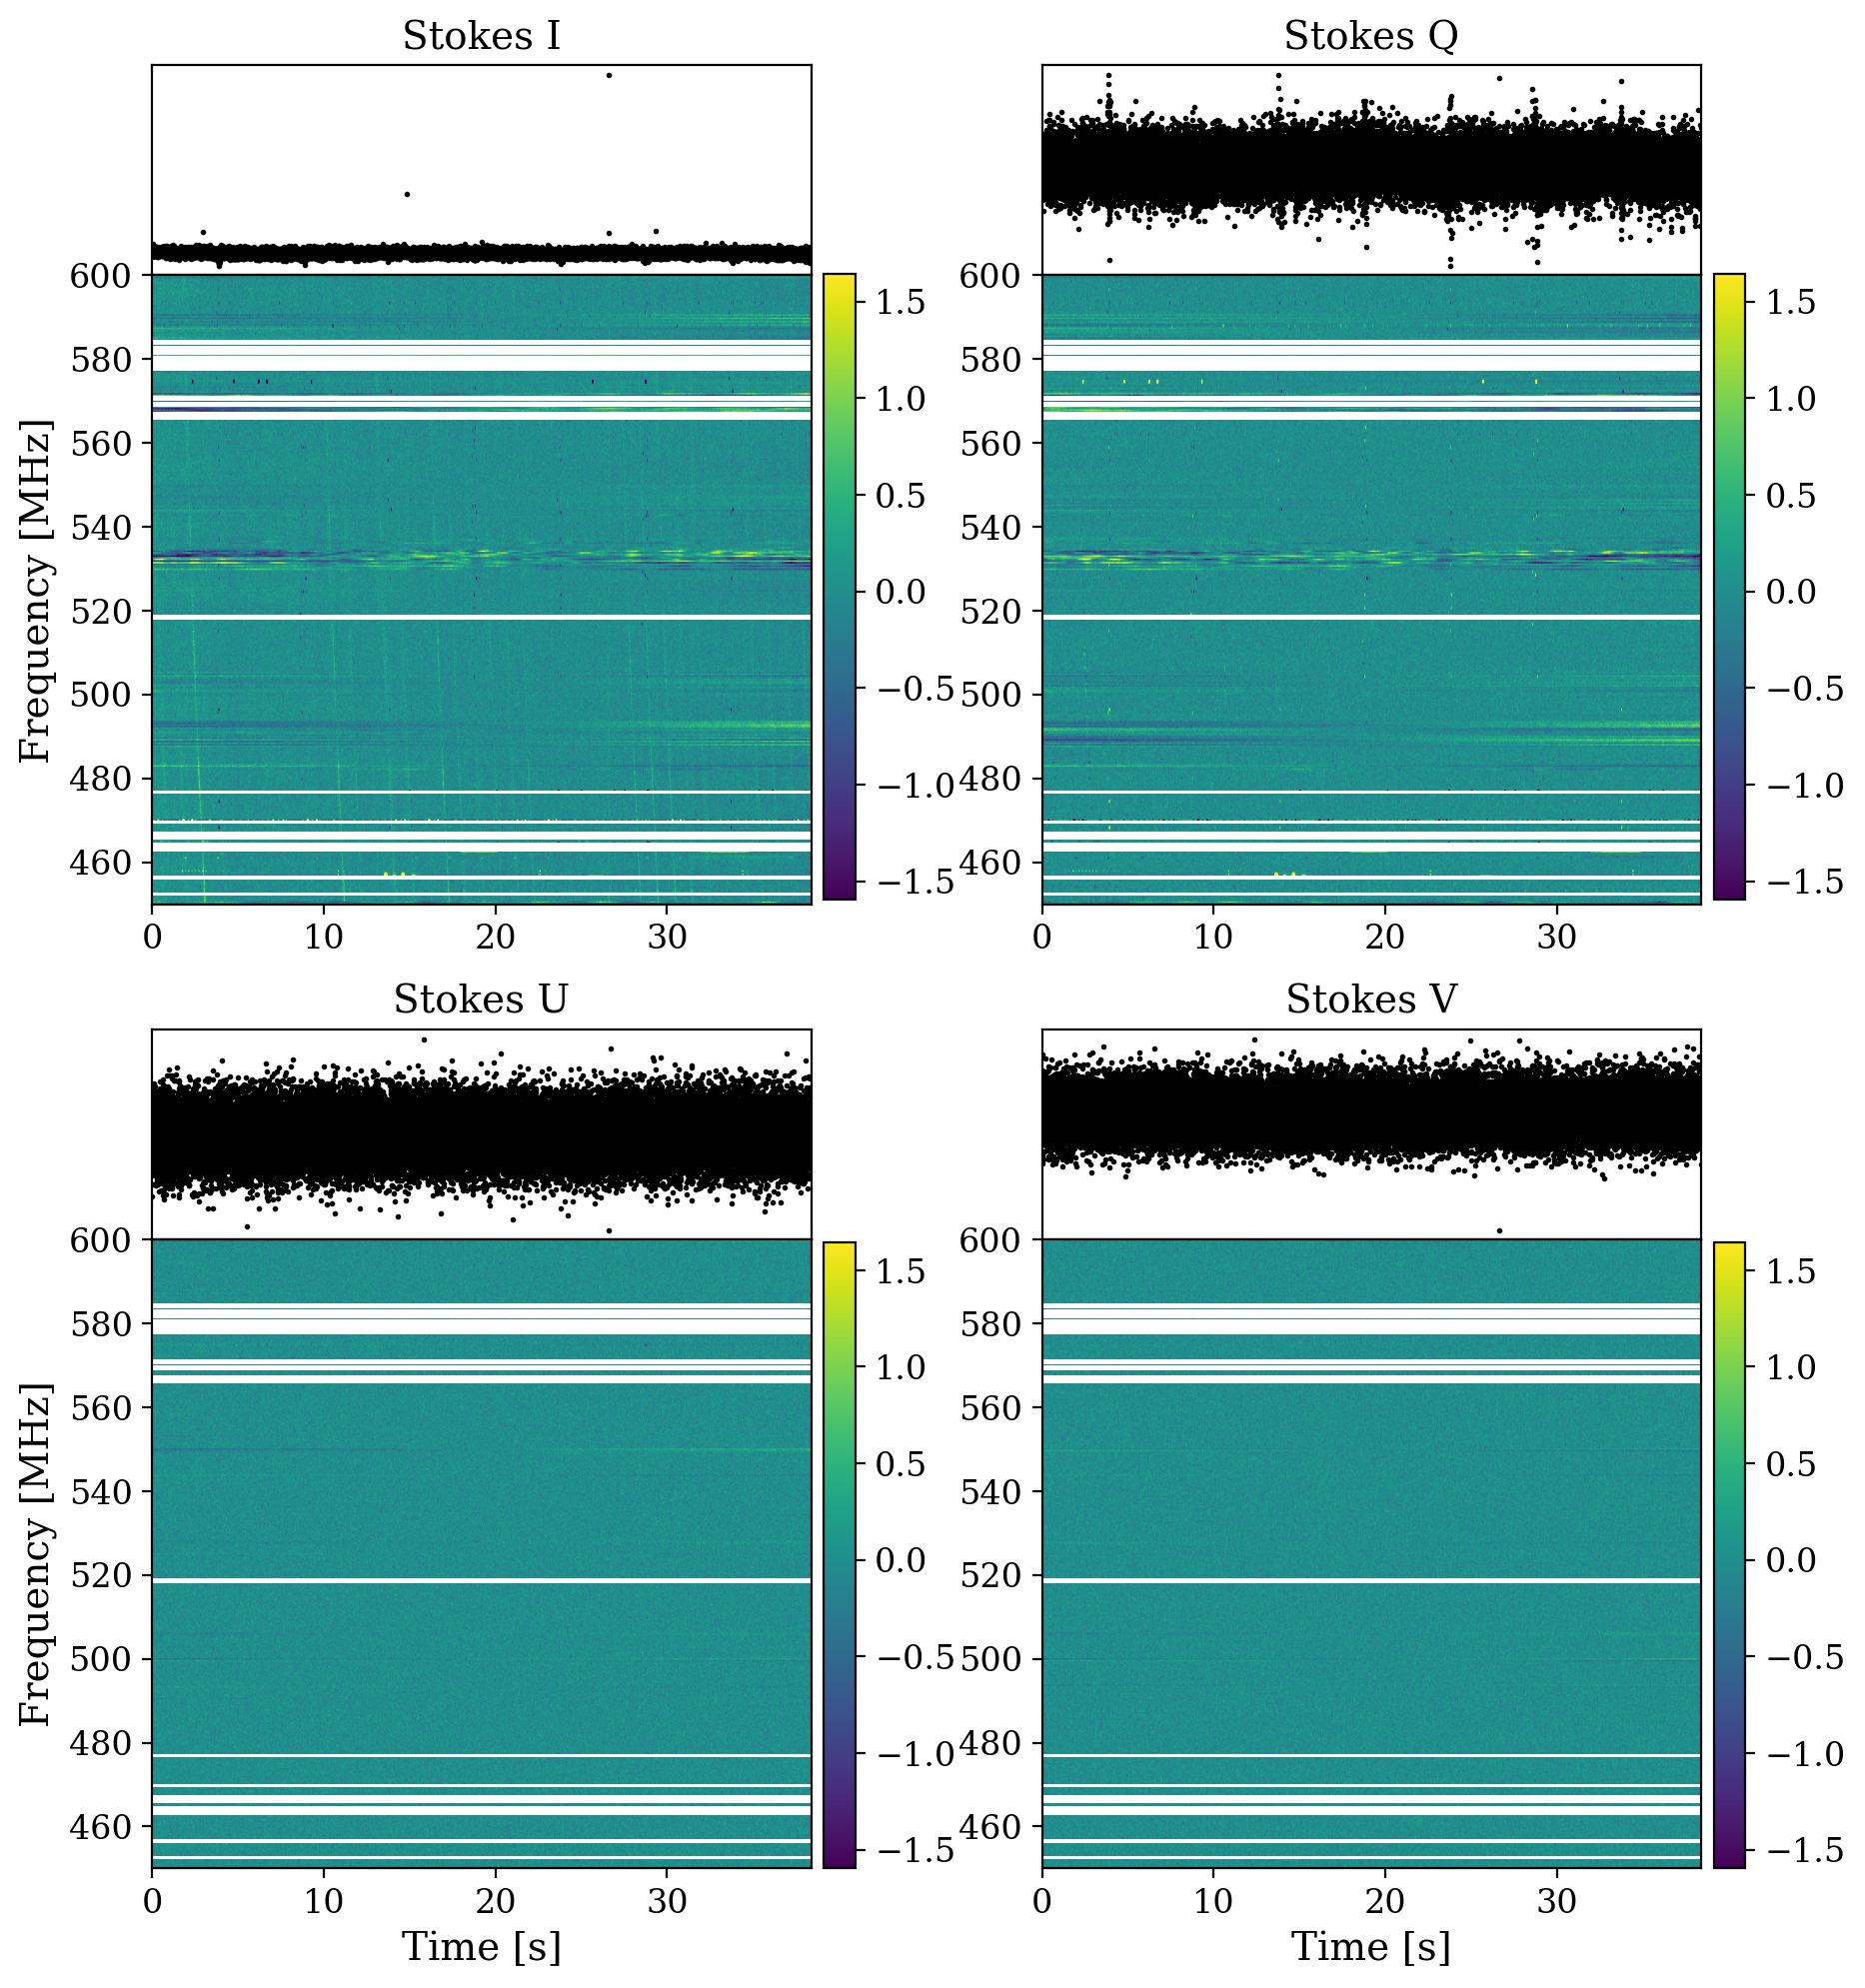

In [30]:
# Plot normalized & masked data
plot_stokes(stokes_norm_masked, freq=freq, time=time, t_unit='s')

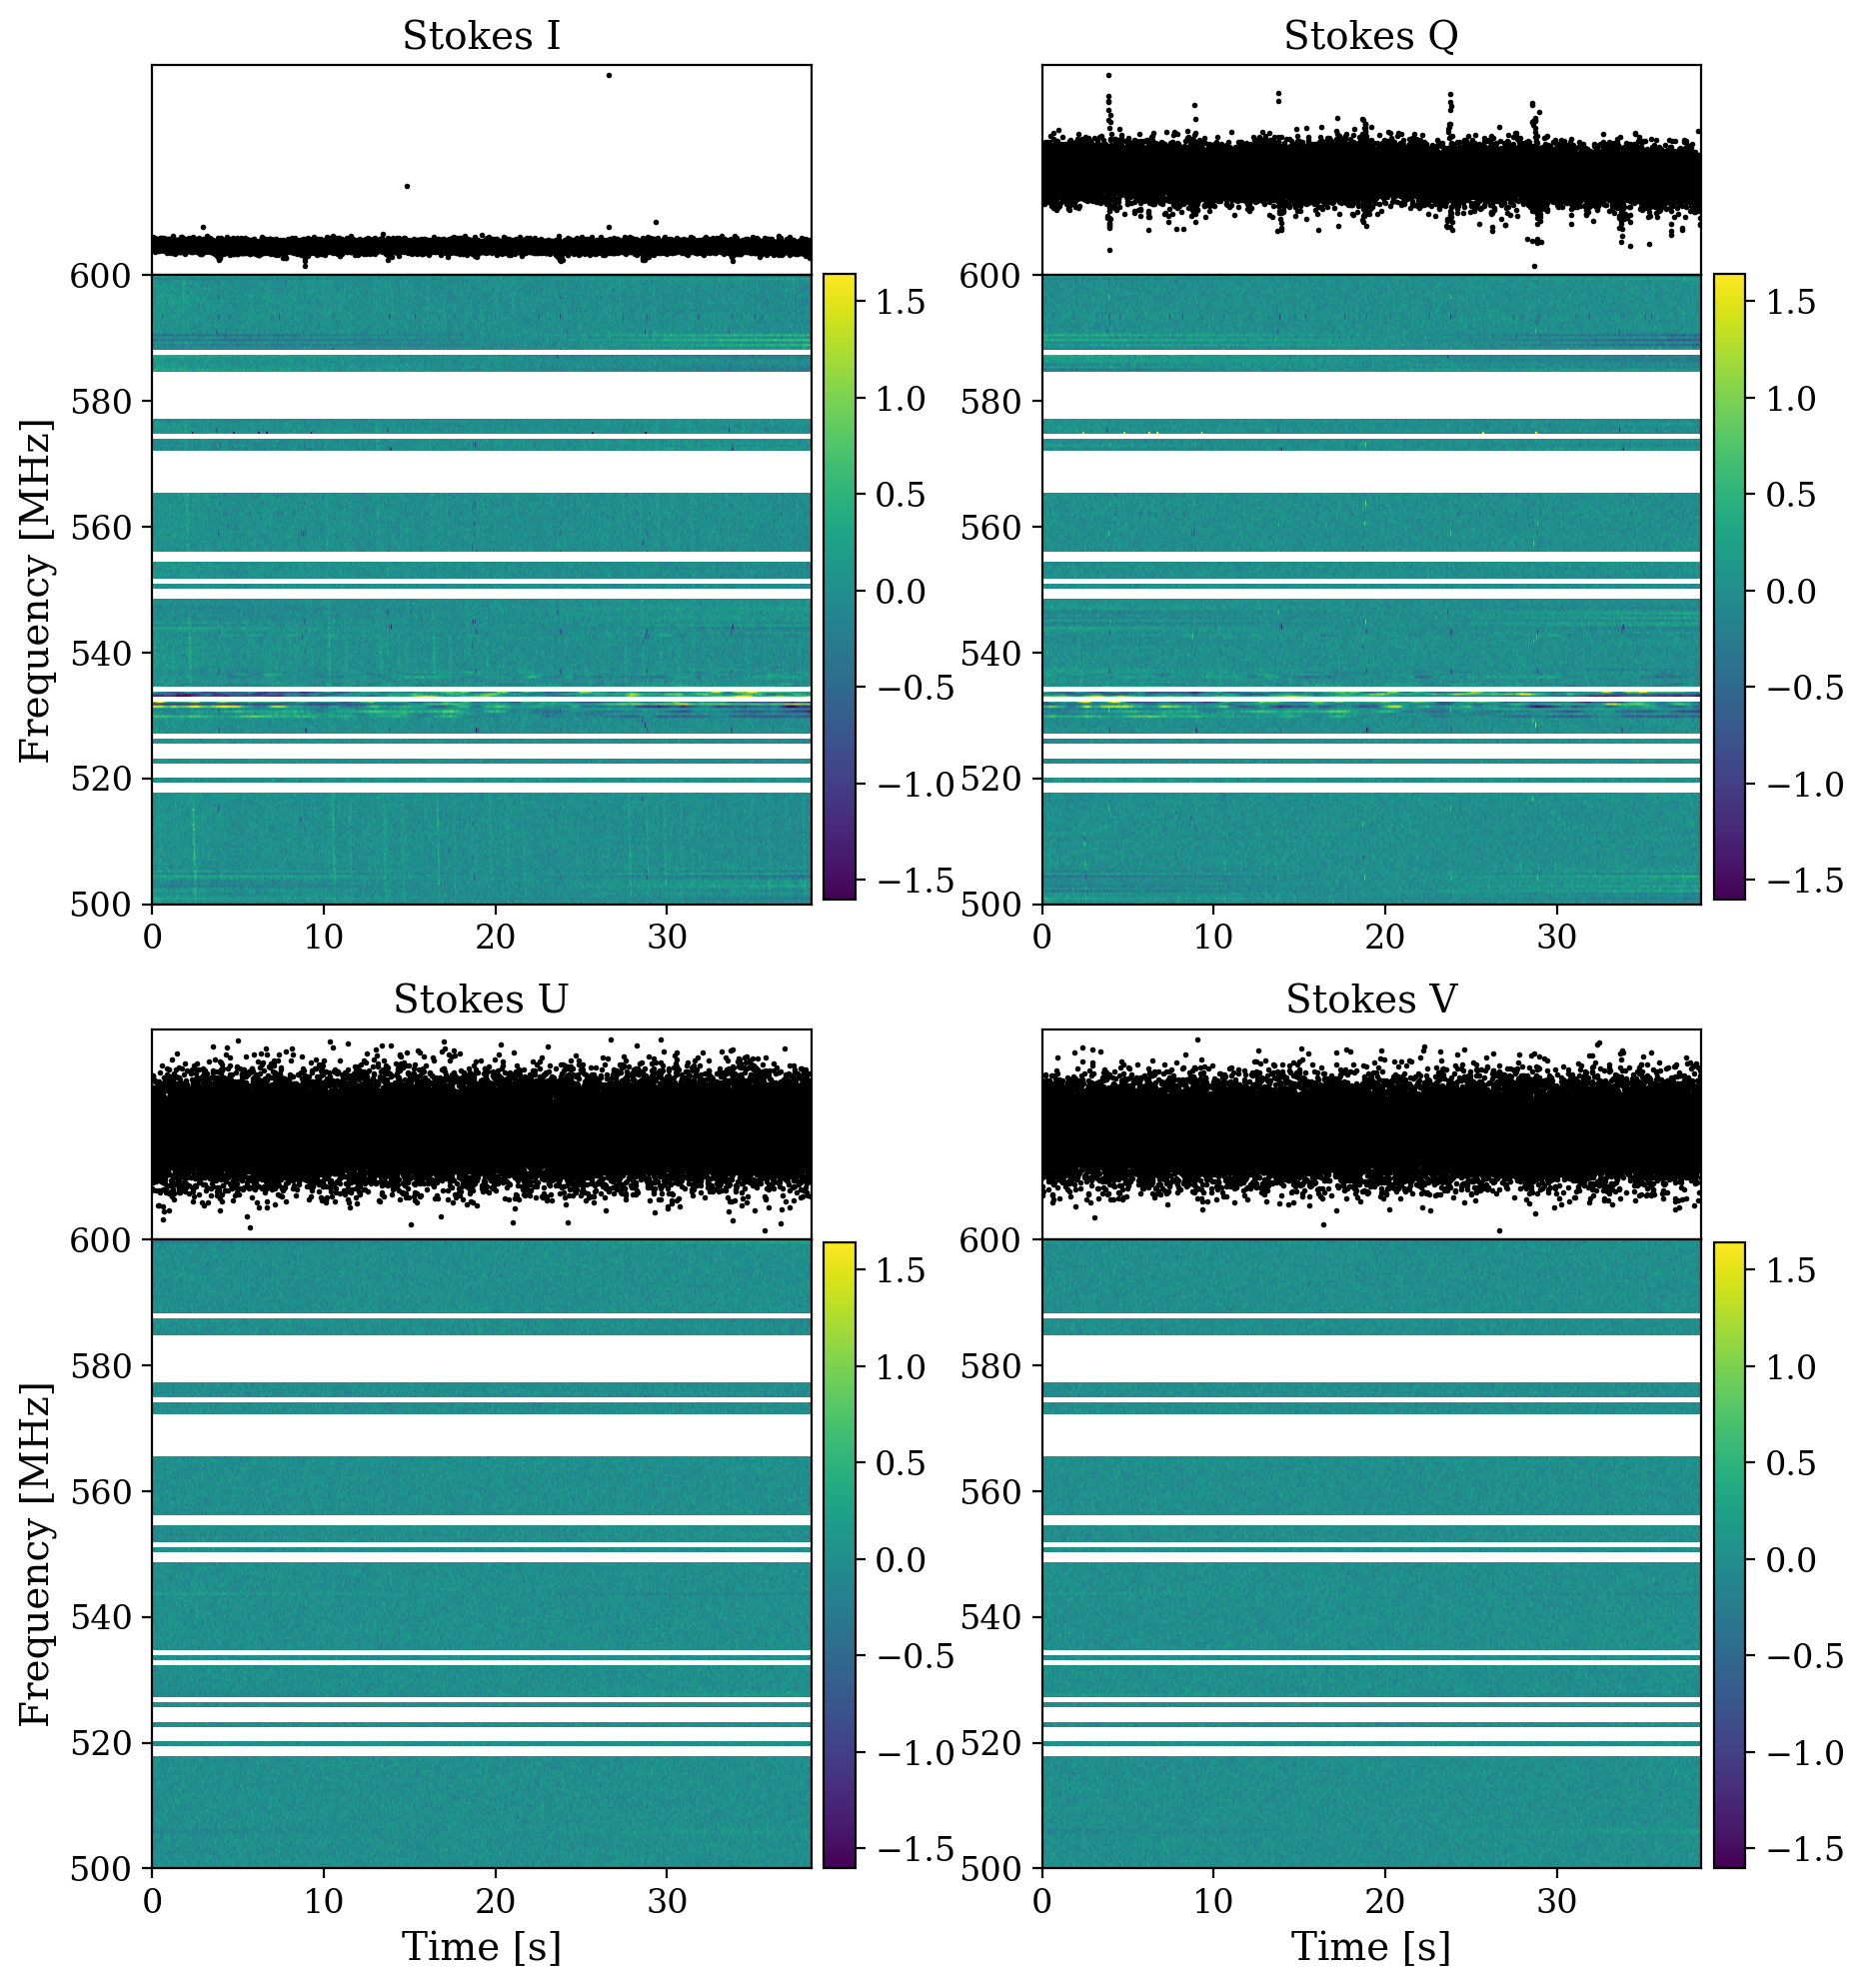

In [ ]:
# # Plot normalized & masked data
# plot_stokes(stokes_norm_masked, freq=freq, time=time, t_unit='s')

# RM Synthesis

### RMSF

$$ R(\phi) = \frac{1}{W} \sum_j W_j e^{-2i\phi(\lambda_j^2)} $$

In [13]:
# Define weight function (with and without masked channels)
W_full = np.ones_like(freq)
W = W_full.copy()
W[rfi_mask] = 0  # Set bad channels to zero (rfi_masked_ch=True where masked)

# lambda^2 array
lambda2_array = (c.value/(freq*1e6))**2  # shape (Nfreqs)
l2_min = np.min(lambda2_array)
l2_max = np.max(lambda2_array)
dl2 = np.median(np.abs(np.diff(lambda2_array)))
Dl2 = l2_max - l2_min  # total range of lambda^2

# phi array
fwhm = 2 * np.sqrt(3) / Dl2  # FWHM of the RMSF
# phi_max = np.sqrt(3)/dl2  # max RM to search
# phi_max = 10 * fwhm  # ~10*FWHM
phi_max = 1500
dphi = 0.05 * fwhm  # spacing between phi values, ~0.1*FWHM
phi_array = np.arange(-phi_max, phi_max + dphi, dphi)  # shape (N_phi,)
N_phi = len(phi_array)

In [14]:
# Compute FSF (RMSF) w/ masked channels
K = 1.0 / np.nansum(W)  # normalization constant
a = (-2.0 * 1j * phi_array).astype('complex64')  # exponent for RMSF
b = np.outer(a, lambda2_array)  # shape (Nphi, Nlambda2)
RMSF = K * np.sum(W * np.exp(b), 1)  # sum along lambda axis & normalize

# RMSF w/ all channels
K_full = 1.0 / np.sum(W_full)  # normalization constant
RMSF_full = K_full * np.sum(W_full * np.exp(b), 1)  # sum along lambda axis & normalize

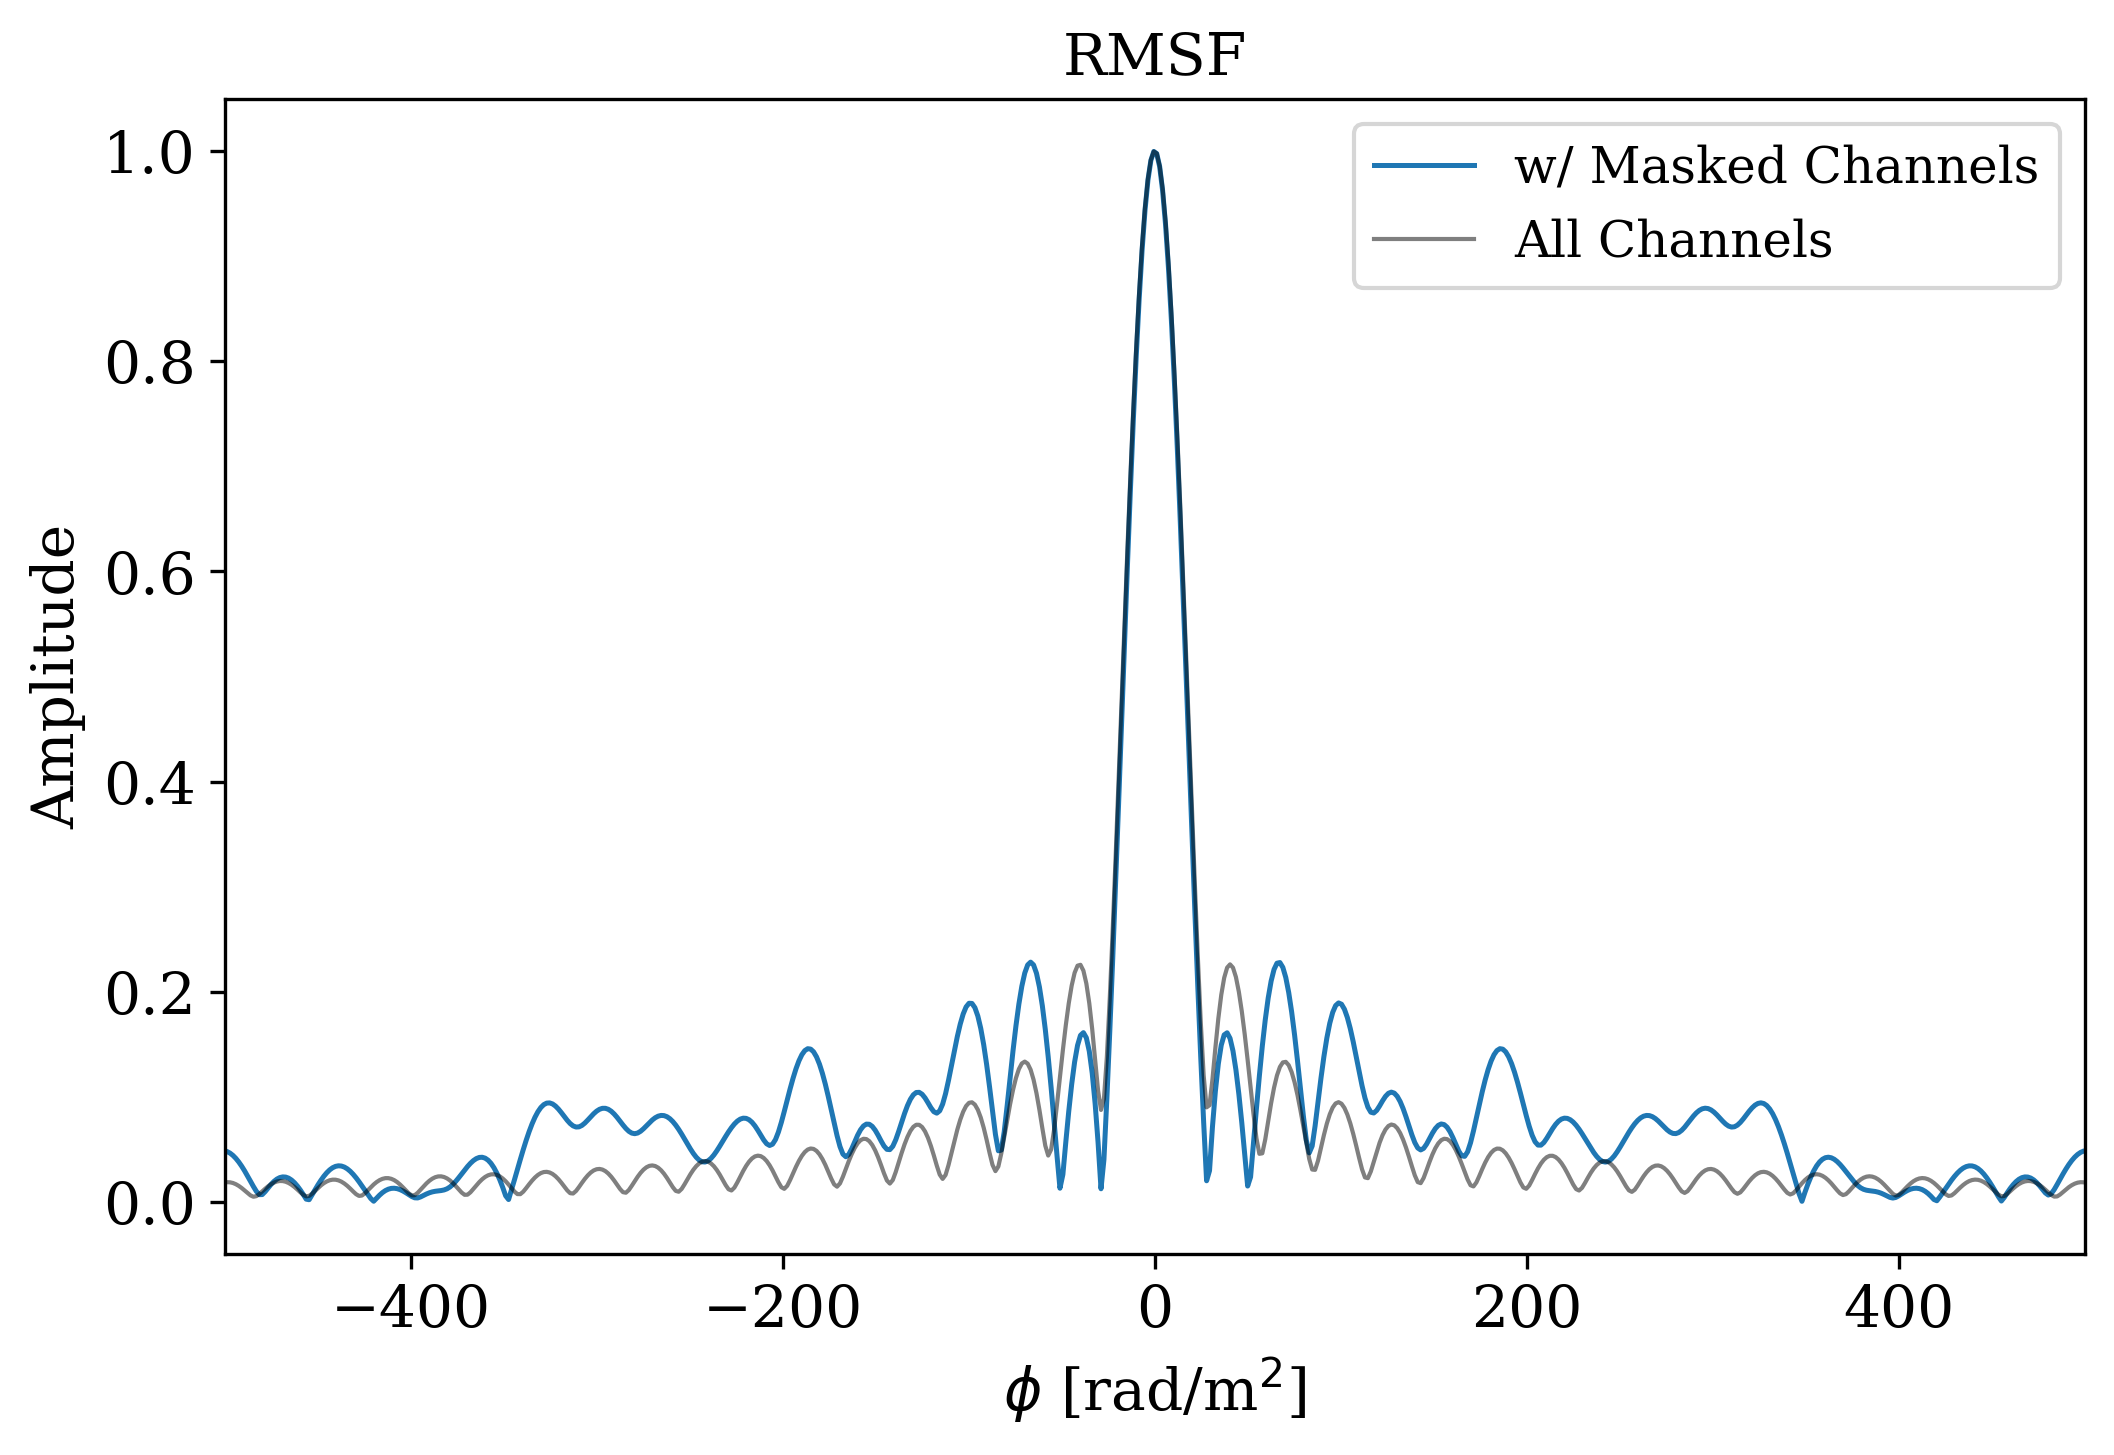

In [20]:
# Plot FSF
plt.figure(figsize=(8, 5))
plt.title('RMSF')

plt.plot(phi_array, np.abs(RMSF), lw=1.2, label='w/ Masked Channels')
plt.plot(phi_array, np.abs(RMSF_full), lw=1, alpha=0.5, c='k', label='All Channels')
plt.xlim(-500,500)

plt.xlabel(r'$\phi$ [rad/m$^2$]')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.show()

### RM Search

In [ ]:
def get_spectra(Q, U, t_range=[0,None], freq=freq, f_range=[0,None], normalize=True, replace_nans=True):
    """
    Calculate (normalized) Q and U spectra.
    Returns normalized Q and U spectra averaged over the specified time range.

    Parameters
    ----------
    Q : Stokes Q array (shape: [Nfreqs, Ntimes]).
    U : Stokes U array (shape: [Nfreqs, Ntimes]).
    t_range : Time range to average over (in indices) [start, stop].
    freq : Frequency array (in MHz), matches Nfreqs.
    f_range : Frequency range to get the spectrum for (in indices) [start, stop].
    normalize : If True, normalize the spectra by L.
    replace_nans : If True, replace NaNs with 0 in the normalized spectra.
    """
    
    # Time average
    f_start, f_stop = f_range
    freq = freq[f_start:f_stop]
    t_start, t_stop = t_range
    Q_spec = np.nanmean((Q)[f_start:f_stop,t_start:t_stop], axis=1)
    U_spec = np.nanmean((U)[f_start:f_stop,t_start:t_stop], axis=1)

    # Normalize
    if normalize:
        L_spec = np.sqrt(Q_spec**2 + U_spec**2)
        Q_spec_norm = Q_spec / L_spec
        U_spec_norm = U_spec / L_spec
    else:
        Q_spec_norm = Q_spec
        U_spec_norm = U_spec

    # Handle NaNs
    if replace_nans:
        Q_spec_norm = np.nan_to_num(Q_spec_norm, nan=0.0)
        U_spec_norm = np.nan_to_num(U_spec_norm, nan=0.0)

    return Q_spec_norm, U_spec_norm



def rm_synthesis(P_spec, lambda_sq, phi_array):
    """
    Perform RM synthesis on the given P spectrum.
    
    Parameters
    ----------
    P_spec : Normalized complex P spectrum (shape: [Nfreqs,]).
    lambda_sq : Squared wavelength array (shape: [Nfreqs,]). In m^2.
    phi_array : Array of phi values to compute the FDF for (shape: [N_phi,]). In rad.

    Returns
    -------
    RM_meas : Phi value at which the peak of the FDF occurs (in rad/m^2).
    FDF : F(phi) for the given P_spec (shape: [N_phi,]).
    """

    # Compute FDF
    K = 1.0 / np.nansum(W)  # normalization constant
    a = (-2.0 * 1j * phi_array).astype('complex64')
    b = np.outer(a, lambda_sq)  # shape (Nphi, Nlambda2)
    FDF = K * np.sum(P_spec * np.exp(b), 1)  # sum along lambda axis & normalize

    # Find peak phi (= RM)
    FDF_peak_ind = np.argmax(np.abs(FDF))
    RM_meas = phi_array[FDF_peak_ind]

    return RM_meas, FDF

In [ ]:
# Time slice parameters
step = 10  # num of time channels to average over
time_slice_arr = time[::step]  # New time array (using start times of each time slice)

# Set up arrays for results
RM_meas_arr = np.zeros(len(time_slice_arr))  # Store peak of FDF for each time slice
FDF_arr = np.zeros((len(time_slice_arr), N_phi), dtype=complex)  # FDF for each time slice

# Step through time & compute FDF
for i,start_time in enumerate(time_slice_arr):
  # Time slice indices
  t_start_ind = np.argwhere(time==start_time)[0][0]
  t_stop_ind = t_start_ind+step

  # Get the spectra (avg over time slice)
  Q_spec_norm, U_spec_norm = get_spectra(stokes_norm_masked[1].T, stokes_norm_masked[2].T, t_range=[t_start_ind, t_stop_ind])
  P_spec_norm = Q_spec_norm + 1j*U_spec_norm

  # Compute FDF and RM for the time slice
  RM_meas_arr[i], FDF_arr[i] = rm_synthesis(P_spec_norm,
                                            lambda_sq=lambda2_array,
                                            phi_array=phi_array,
                                          )

# Normalize FDF
# FDF_norm = np.abs(FDF_arr) / np.max(np.abs(FDF_arr), axis=1)[:,None]  # Normalize each FDF by its max

/tmp/ipykernel_2492075/802324890.py:21: RuntimeWarning: Mean of empty slice
  Q_spec = np.nanmean((Q)[f_start:f_stop,t_start:t_stop], axis=1)
/tmp/ipykernel_2492075/802324890.py:22: RuntimeWarning: Mean of empty slice
  U_spec = np.nanmean((U)[f_start:f_stop,t_start:t_stop], axis=1)


### FDF Plots

In [24]:
def plot_2panels(data, time, phi, cbar_label='', plot_true=False, height_ratios=[1, 3],
                 ax1_type='peak', ax2_ylabel=r'$\phi$ [rad/m$^2$]', t_unit='ms',
                 xlim=None, ylim=None, suptitle=None):
    """
    Make a 2-panel phi/time plot of some data.

    Parameters
    ----------
    data : Data to plot (shape: [Ntimes, Nphi]). Absolute value is taken.
    time : Time array (shape: [Ntimes]).
    phi : Phi array (shape: [Nphi]).
    cbar_label : Colorbar label.
    plot_true : If True, plot the true burst times as vertical dashed lines.
    height_ratios : Ratios of the heights of the two panels.
    ax1_type : Type of the first panel ('peak' for peak amplitude, 'mean' for mean amplitude).
    t_unit : Unit for the time axis (e.g., 'ms', 's').
    """
    
    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        gridspec_kw={'height_ratios':height_ratios, 'right':0.85, 'hspace':0}, 
        sharex=True,
        figsize=(8, 8),
        dpi=150
    )

    # AX1: True bursts
    if plot_true:
        ax1.axvline(TIME_TRUE[0], color='grey', linestyle='--', label='True bursts')
        ax1.axvline(TIME_TRUE[1], color='grey', linestyle='--')
        ax1.legend(loc='upper left')

    # AX1: Get peak or avg for each time slice
    peak = np.max(np.abs(data), axis=1) if ax1_type=='peak' else np.mean(np.abs(data), axis=1)
    ax1.plot(time, peak, lw=0.8, c='rebeccapurple')
    ax1_label = 'Peak Amp.' if ax1_type == 'peak' else 'Avg. Amp.'
    ax1.set_ylabel(ax1_label)


    # AX2: Plot data
    extent = (time[0], time[-1], phi[0], phi[-1])
    im = ax2.imshow(np.abs(data).T,  # shape (Ntimes, Nphi).T
                    aspect='auto',
                    origin='lower',
                    extent=extent,
                    cmap='viridis'
                    )
    ax2.set_xlabel(f'Time [{t_unit}]')
    ax2.set_ylabel(ax2_ylabel)
    if xlim is not None:
        ax2.set_xlim(xlim)
    if ylim is not None:
        ax2.set_ylim(ylim)
    
	# Colorbar
    cbar = fig.colorbar(im, ax=(ax1, ax2), pad=0.02, 
                        shrink=height_ratios[1]/np.sum(height_ratios), 
                        anchor=(0.0, 0.0)
                        )
    cbar.set_label(cbar_label)
    
    if suptitle is not None:
        ax1.set_title(suptitle)
    # plt.tight_layout()
    plt.show()

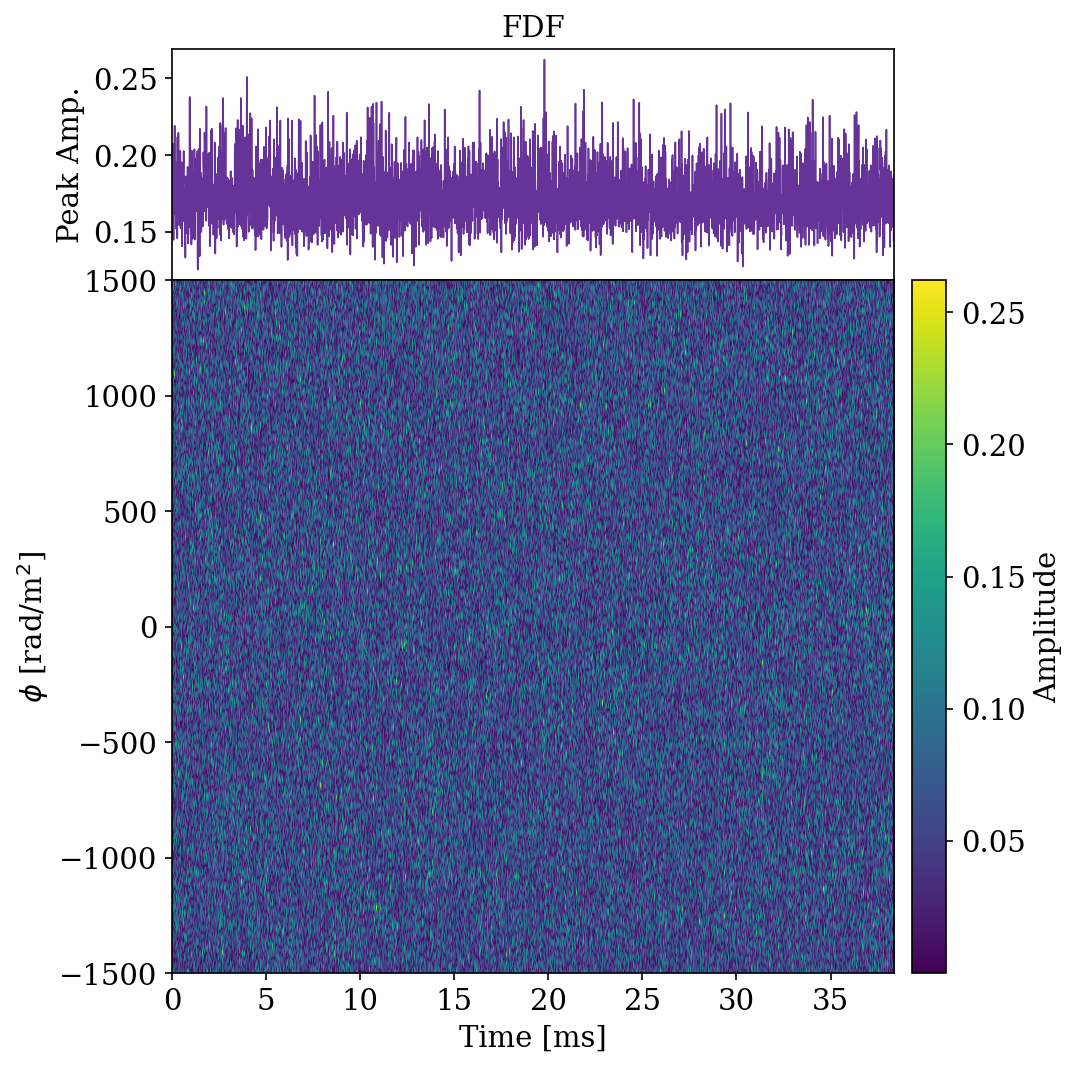

In [25]:
plot_2panels(FDF_arr, time_slice_arr, phi_array, cbar_label='Amplitude', plot_true=False,
             suptitle='FDF')#, ylim=(-700,700))

### Cross-Correlating

In [29]:
# Cross-correlate measured FDF with FSF for each time slice
mode = 'full'
cross_corr_len = 2 * len(phi_array) - 1

# Compute cross-correlation for each time slice
cross_corr_arr = np.zeros((len(time_slice_arr), cross_corr_len))  # shape (Ntimes, Nphi)

for i,t in enumerate(time_slice_arr):
    # Get absolute value of FDF for the time slice
    fdf_slice = np.abs(FDF_arr[i])
    # Normalize FDF slice to match FSF normalization
    # fdf_slice /= np.max(fdf_slice)  # Normalize to max value of FDF slice
    
    # Cross-correlate with FSF
    cross_corr_arr[i] = correlate(fdf_slice, np.abs(RMSF), mode='full')

# Get channel lags and corresponding phi values
channel_lags = correlation_lags(len(phi_array), len(phi_array), mode='full')
phi_lags = channel_lags * dphi  # Convert channel lags to phi values

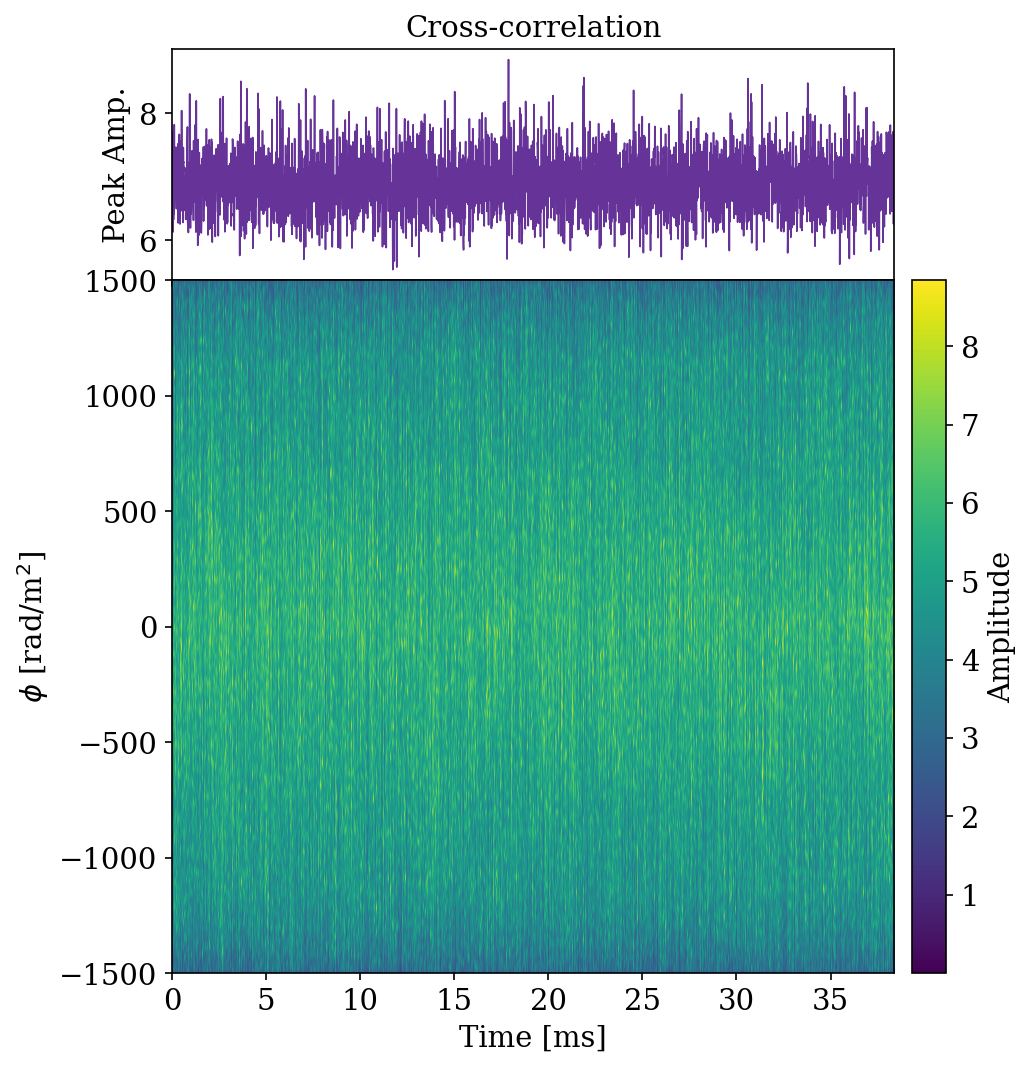

In [30]:
# Plot
plot_2panels(cross_corr_arr, time_slice_arr, phi_lags, ax2_ylabel=r'$\phi$ [rad/m$^2$]', 
			cbar_label='Amplitude', ax1_type='peak', suptitle='Cross-correlation', ylim=(-1500,1500))

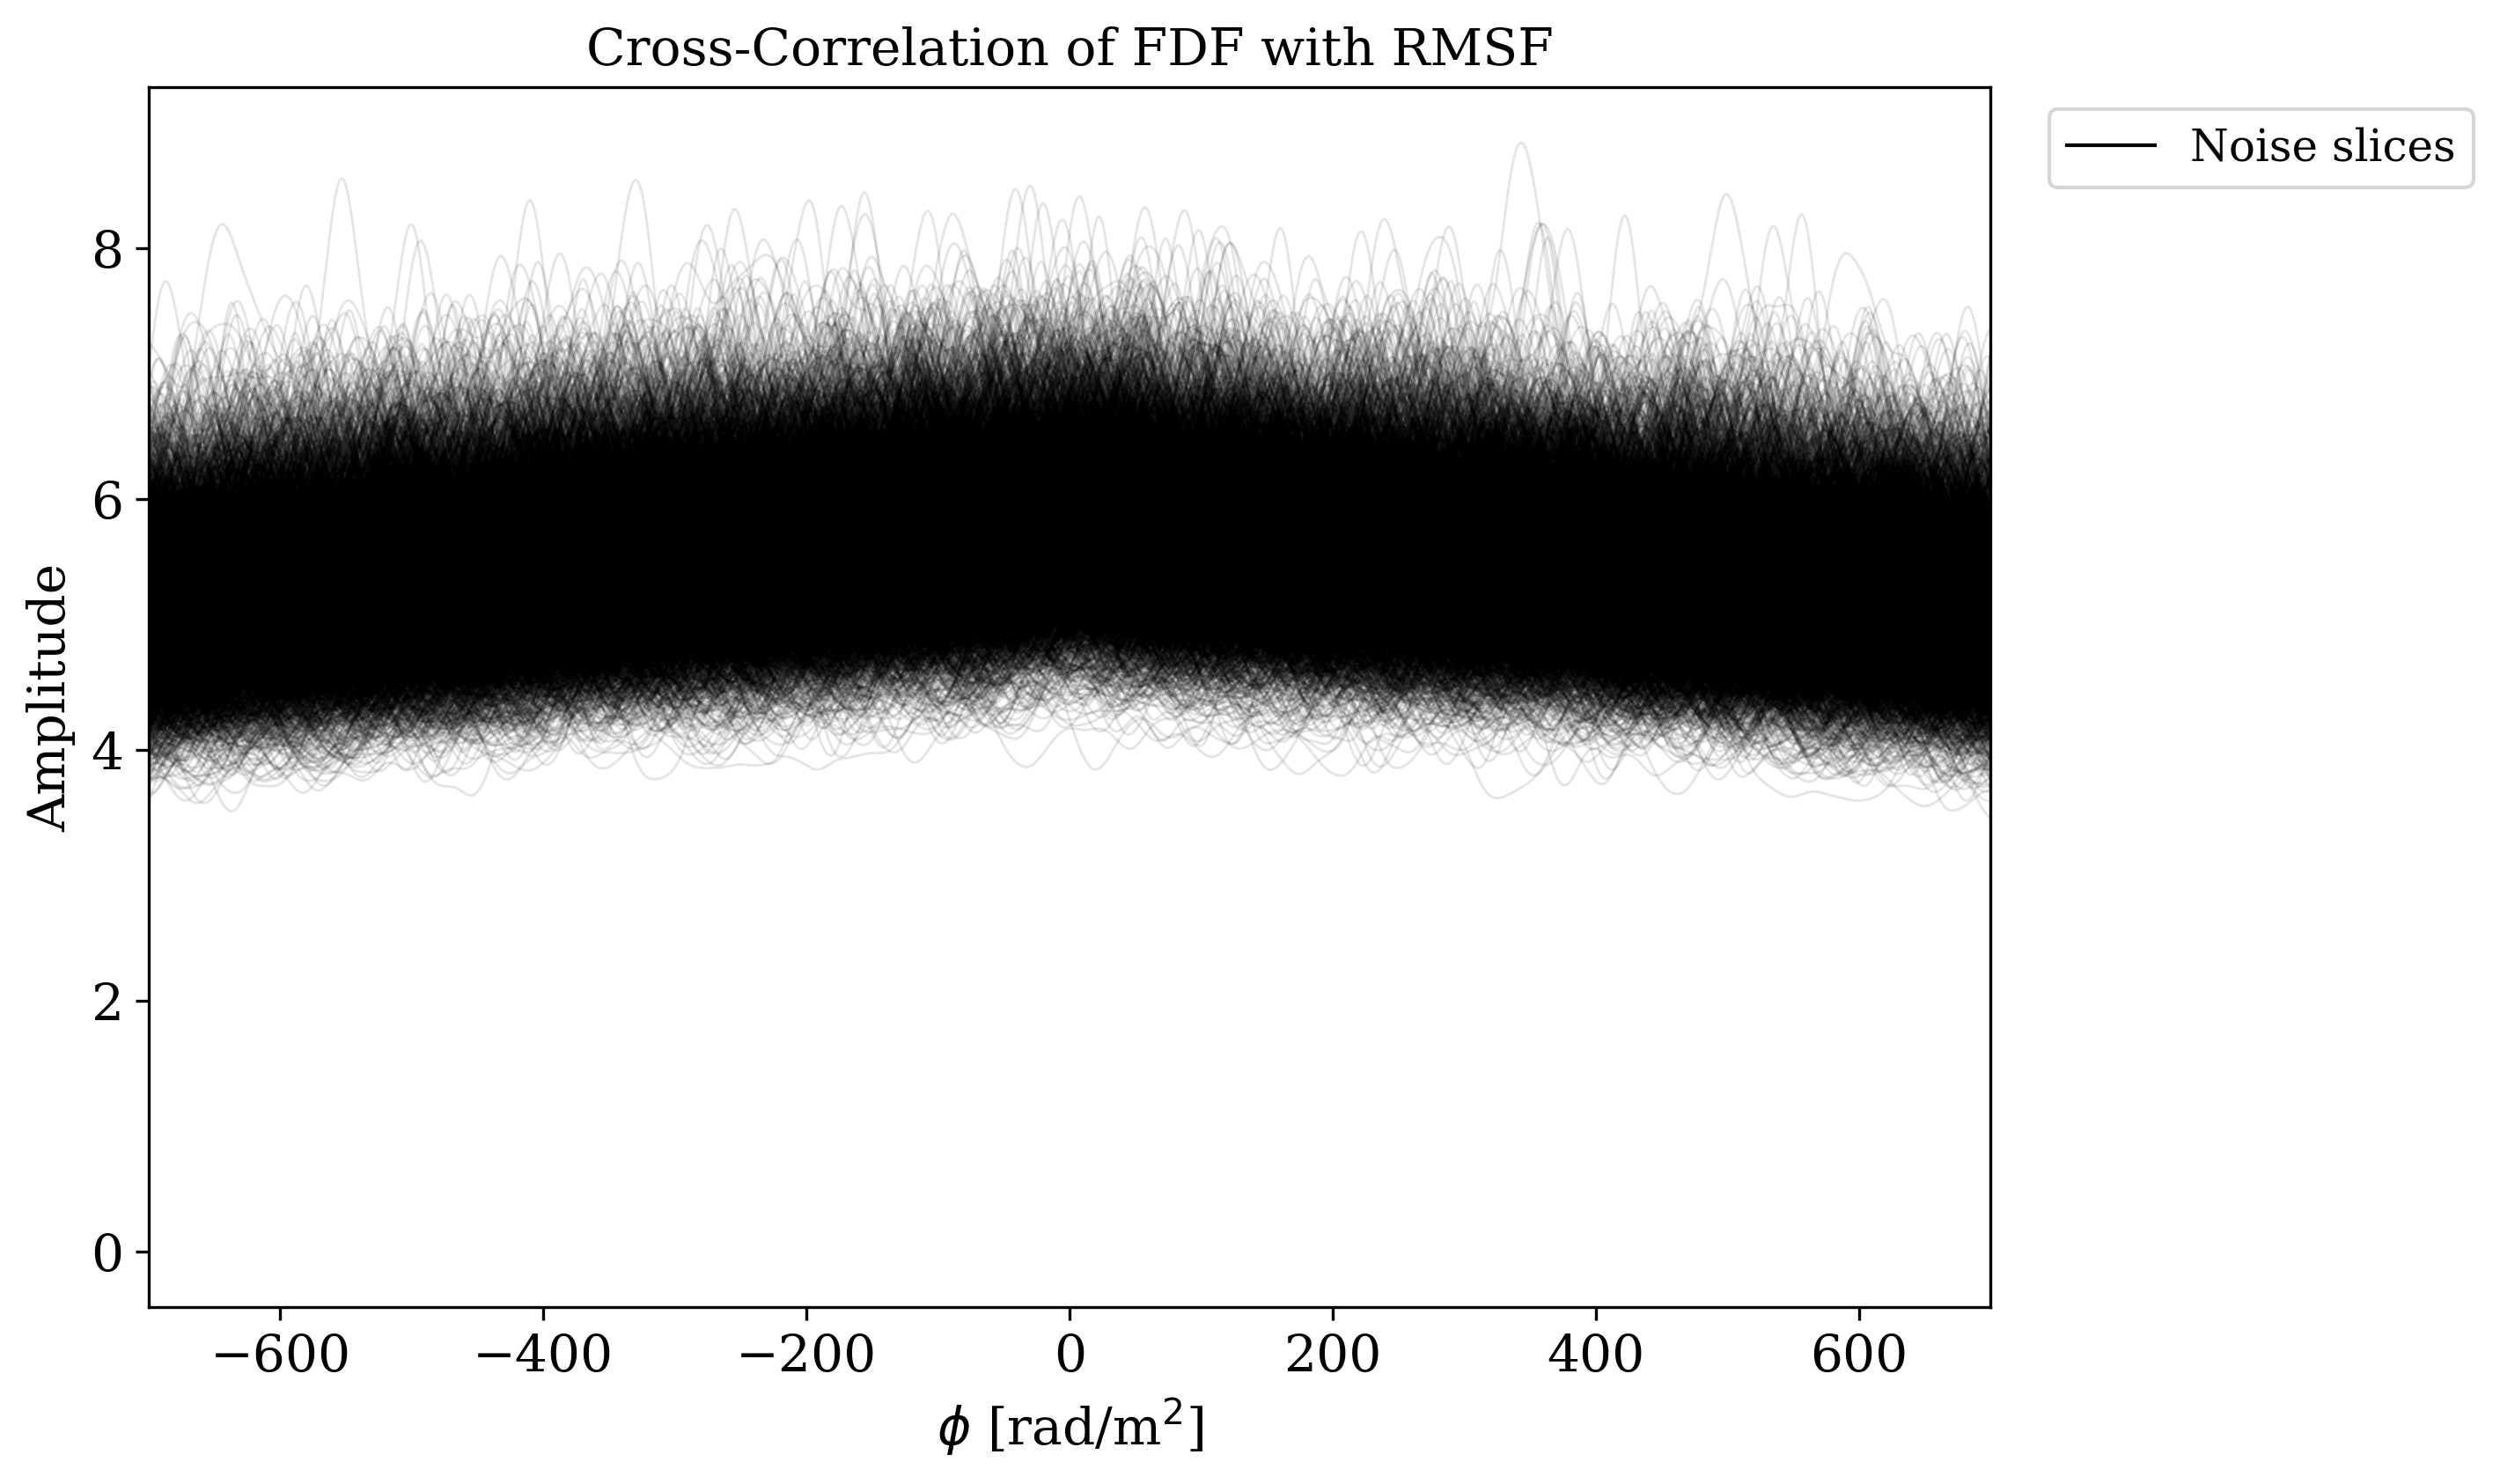

In [31]:
# --- Plotting by slice ---
# ind1 = np.argmin(np.abs(time_slice_arr - TIME_TRUE[0]))
# ind2 = np.argmin(np.abs(time_slice_arr - TIME_TRUE[1]))

plt.figure(figsize=(9, 6))
plt.title('Cross-Correlation of FDF with RMSF')

for i,t_slice in enumerate(cross_corr_arr):
    # color = 'dodgerblue' if i in [ind1-1, ind1, ind1+1] else ('orange' if i in [ind2-1, ind2, ind2+1] else 'black')
    color = 'k'
    plt.plot(phi_lags, abs(t_slice), color=color, alpha=0.1, lw=0.7)

# plt.plot(phi_lags, abs(cross_corr_arr[ind1]), color='dodgerblue', label=f'Burst 1 ({time_slice_arr[ind1]:.1f} {t_unit})')
# plt.plot(phi_lags, abs(cross_corr_arr[ind2]), color='orange', label=f'Burst 2 ({time_slice_arr[ind2]:.1f} {t_unit})')
plt.plot([], [], color='black', alpha=1, lw=1, label='Noise slices')

# plt.axvline(x=RM_true[0], label='True RM 1', 
#             color='dodgerblue', linestyle='--', alpha=0.6)
# plt.axvline(x=RM_true[1], label='True RM 2', 
#             color='orange', linestyle='--', alpha=0.6)

plt.xlabel(r'$\phi$ [rad/m$^2$]')
plt.ylabel('Amplitude')
plt.xlim(-700, 700)

plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.show()